<a href="https://colab.research.google.com/github/AbiniveshMayilsamy/DSindustrychallenge-Q50/blob/main/DS50.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Setup and Environment Configuration

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['figure.dpi'] = 120

## 2. Load, Clean, and Validate HR Dataset

In [ ]:
possible_paths = [
    'employee_performance_workload_attrition.csv',
    'd:/DS individual challenge/Q50/employee_performance_workload_attrition.csv',
    'hr_data.csv',
    'd:/DS individual challenge/Q50/hr_data.csv'
]

data_path = next((p for p in possible_paths if os.path.exists(p)), 'employee_performance_workload_attrition.csv')

df = pd.read_csv(data_path)
display(df.head(10))
print(f"\nLoaded dataset from: {data_path}")
df.info()

print("\nMissing Values Count:")
display(df.isnull().sum())

# Data validation & cleaning
numeric_cols = ['monthly_salary', 'avg_weekly_hours', 'projects_handled', 'performance_rating', 'absences_days', 'job_satisfaction']
for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

df.dropna(inplace=True)
df.drop_duplicates(inplace=True)

# Derive core workload and overtime metrics
# Standard work week = 40 hours
df['overtime_hours'] = (df['avg_weekly_hours'] - 40).clip(lower=0)
df['workload_per_project'] = df['avg_weekly_hours'] / df['projects_handled'].replace(0, 1)
df['hours_per_absence'] = df['avg_weekly_hours'] / (df['absences_days'] + 1)
df['is_overworked'] = ((df['avg_weekly_hours'] >= 50) | (df['projects_handled'] >= 5)).astype(int)
df['is_chronic_overload'] = ((df['avg_weekly_hours'] >= 55) & (df['projects_handled'] >= 6)).astype(int)

# Encode attrition
df['attrition_binary'] = (df['attrition'] == 'Yes').astype(int)

print(f"Cleaned dataset rows: {len(df):,}")
display(df.describe())

,employee_id,department,role_level,monthly_salary,avg_weekly_hours,projects_handled,performance_rating,absences_days,job_satisfaction,attrition
0,1,HR,Junior,81750,55,1,1,17,1,Yes
1,2,Engineering,Senior,58140,36,2,4,13,1,Yes
2,3,Finance,Mid,37747,61,2,2,20,5,No
3,4,Finance,Senior,81993,36,4,1,17,2,Yes
4,5,Sales,Senior,45439,53,5,5,5,1,No
5,6,Operations,Junior,78810,38,2,5,1,5,No
6,7,Operations,Senior,86045,59,6,4,18,4,Yes
7,8,Sales,Junior,61994,37,5,5,15,3,No
8,9,HR,Senior,39594,38,7,2,10,2,No
9,10,Marketing,Junior,117584,37,6,3,11,5,No



Loaded dataset from: employee_performance_workload_attrition.csv
<class 'pandas.DataFrame'>
RangeIndex: 2800 entries, 0 to 2799
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   employee_id         2800 non-null   int64
 1   department          2800 non-null   str  
 2   role_level          2800 non-null   str  
 3   monthly_salary      2800 non-null   int64
 4   avg_weekly_hours    2800 non-null   int64
 5   projects_handled    2800 non-null   int64
 6   performance_rating  2800 non-null   int64
 7   absences_days       2800 non-null   int64
 8   job_satisfaction    2800 non-null   int64
 9   attrition           2800 non-null   str  
dtypes: int64(7), str(3)
memory usage: 259.3 KB

Missing Values Count:


employee_id           0
department            0
role_level            0
monthly_salary        0
avg_weekly_hours      0
projects_handled      0
performance_rating    0
absences_days         0
job_satisfaction      0
attrition             0
dtype: int64

Cleaned dataset rows: 2,800


,employee_id,monthly_salary,avg_weekly_hours,projects_handled,performance_rating,absences_days,job_satisfaction,overtime_hours,workload_per_project,hours_per_absence,is_overworked,is_chronic_overload,attrition_binary
count,2800.000000,2800.000000,2800.000000,2800.000000,2800.000000,2800.000000,2800.000000,2800.000000,2800.000000,2800.000000,2800.000000,2800.000000,2800.000000
mean,1400.500000,74492.075000,49.842500,4.519286,2.960714,9.995000,2.995357,10.351429,16.843259,8.801991,0.761786,0.130714,0.407143
std,808.434702,25899.209391,8.980976,2.286778,1.404794,6.056656,1.414332,8.275840,14.378433,11.314967,0.426067,0.337148,0.491390
min,1.000000,30006.000000,35.000000,1.000000,1.000000,0.000000,1.000000,0.000000,4.375000,1.666667,0.000000,0.000000,0.000000
25%,700.750000,51665.000000,42.000000,3.000000,2.000000,5.000000,2.000000,2.000000,7.666667,3.071429,1.000000,0.000000,0.000000
50%,1400.500000,74587.500000,50.000000,4.000000,3.000000,10.000000,3.000000,10.000000,11.200000,4.461538,1.000000,0.000000,0.000000
75%,2100.250000,97249.500000,57.000000,7.000000,4.000000,15.000000,4.000000,17.000000,19.500000,8.666667,1.000000,0.000000,1.000000
max,2800.000000,119977.000000,65.000000,8.000000,5.000000,20.000000,5.000000,25.000000,65.000000,65.000000,1.000000,1.000000,1.000000


## 3. Team-Level Workload and Overtime Aggregation

In [ ]:
team_metrics = df.groupby('department').agg(
    Employee_Count=('employee_id', 'count'),
    Avg_Weekly_Hours=('avg_weekly_hours', 'mean'),
    Total_Weekly_Hours=('avg_weekly_hours', 'sum'),
    Avg_Overtime_Hours=('overtime_hours', 'mean'),
    Avg_Projects=('projects_handled', 'mean'),
    Total_Projects=('projects_handled', 'sum'),
    Avg_Satisfaction=('job_satisfaction', 'mean'),
    Avg_Absences=('absences_days', 'mean'),
    Overworked_Employee_Pct=('is_overworked', lambda x: x.mean() * 100),
    Chronic_Overload_Pct=('is_chronic_overload', lambda x: x.mean() * 100),
    Attrition_Rate_Pct=('attrition_binary', lambda x: x.mean() * 100)
).reset_index()

team_metrics['Workload_Per_Employee'] = team_metrics['Total_Weekly_Hours'] / team_metrics['Employee_Count']
team_metrics = team_metrics.sort_values('Avg_Overtime_Hours', ascending=False).reset_index(drop=True)

print("=== Team-Level Workload & Overtime Summary Table ===")
display(team_metrics)

=== Team-Level Workload & Overtime Summary Table ===


,department,Employee_Count,Avg_Weekly_Hours,Total_Weekly_Hours,Avg_Overtime_Hours,Avg_Projects,Total_Projects,Avg_Satisfaction,Avg_Absences,Overworked_Employee_Pct,Chronic_Overload_Pct,Attrition_Rate_Pct,Workload_Per_Employee
0,Engineering,469,50.206823,23547,10.707889,4.594883,2155,2.957356,10.117271,78.678038,14.925373,39.658849,50.206823
1,Operations,464,50.114224,23253,10.584052,4.450431,2065,2.969828,9.747845,77.801724,12.284483,42.887931,50.114224
2,Sales,434,50.034562,21715,10.527650,4.518433,1961,2.956221,9.910138,71.889401,15.668203,37.557604,50.034562
3,Marketing,494,49.627530,24516,10.190283,4.520243,2233,3.068826,9.874494,77.125506,12.145749,39.473684,49.627530
4,Finance,461,49.607375,22869,10.121475,4.583514,2113,2.911063,9.889371,75.488069,11.713666,42.733189,49.607375
5,HR,478,49.495816,23659,10.004184,4.449791,2127,3.098326,10.418410,75.732218,11.924686,41.841004,49.495816


## 4. Workload, Overtime, Satisfaction, and Attrition Diagnostics

In [ ]:
# Workload vs Satisfaction Analysis
sat_analysis = df.groupby('job_satisfaction').agg(
    Employee_Count=('employee_id', 'count'),
    Mean_Weekly_Hours=('avg_weekly_hours', 'mean'),
    Mean_Overtime_Hours=('overtime_hours', 'mean'),
    Mean_Projects=('projects_handled', 'mean'),
    Mean_Absences=('absences_days', 'mean'),
    Attrition_Rate_Pct=('attrition_binary', lambda x: x.mean() * 100)
).reset_index()

print("=== Metrics Grouped by Job Satisfaction Score ===")
display(sat_analysis)

# Workload Spike vs Chronic Overload Classification
df['workload_category'] = 'Normal Workload (<45 hrs)'
df.loc[(df['avg_weekly_hours'] >= 45) & (df['avg_weekly_hours'] < 55), 'workload_category'] = 'Moderate Workload (45-54 hrs)'
df.loc[(df['avg_weekly_hours'] >= 55) & (df['projects_handled'] < 6), 'workload_category'] = 'Temporary Workload Spike (55+ hrs, Low Projects)'
df.loc[(df['avg_weekly_hours'] >= 55) & (df['projects_handled'] >= 6), 'workload_category'] = 'Chronic Overload (55+ hrs, 6+ Projects)'

spike_analysis = df.groupby('workload_category').agg(
    Headcount=('employee_id', 'count'),
    Avg_Weekly_Hours=('avg_weekly_hours', 'mean'),
    Avg_Overtime=('overtime_hours', 'mean'),
    Avg_Satisfaction=('job_satisfaction', 'mean'),
    Attrition_Rate_Pct=('attrition_binary', lambda x: x.mean() * 100)
).reset_index()

print("\n=== Temporary Spikes vs. Chronic Overload Breakdown ===")
display(spike_analysis)

=== Metrics Grouped by Job Satisfaction Score ===


,job_satisfaction,Employee_Count,Mean_Weekly_Hours,Mean_Overtime_Hours,Mean_Projects,Mean_Absences,Attrition_Rate_Pct
0,1,537,50.044693,10.553073,4.646182,10.361266,57.169460
1,2,624,49.950321,10.399038,4.782051,9.929487,56.891026
2,3,525,49.588571,10.133333,4.361905,9.718095,29.904762
3,4,543,50.322284,10.760589,4.392265,10.200737,28.913444
4,5,571,49.311734,9.921191,4.378284,9.781086,28.721541



=== Temporary Spikes vs. Chronic Overload Breakdown ===


,workload_category,Headcount,Avg_Weekly_Hours,Avg_Overtime,Avg_Satisfaction,Attrition_Rate_Pct
0,"Chronic Overload (55+ hrs, 6+ Projects)",366,59.926230,19.926230,2.841530,53.551913
1,Moderate Workload (45-54 hrs),890,49.635955,9.635955,3.017978,33.820225
2,Normal Workload (<45 hrs),935,39.474866,0.998930,3.005348,37.112299
3,"Temporary Workload Spike (55+ hrs, Low Projects)",609,60.001642,20.001642,3.039409,48.604269


## 5. Random Forest Model Training and Evaluation

In [ ]:
# Feature Engineering for Random Forest
encoded_df = pd.get_dummies(df, columns=['department', 'role_level'], drop_first=False)

feature_cols = [
    'monthly_salary', 'avg_weekly_hours', 'overtime_hours', 'projects_handled',
    'workload_per_project', 'performance_rating', 'absences_days', 'job_satisfaction'
] + [c for c in encoded_df.columns if c.startswith('department_') or c.startswith('role_level_')]

X = encoded_df[feature_cols]
y = encoded_df['attrition_binary']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=4,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)
y_proba = rf_model.predict_proba(X_test)[:, 1]

print("=== Random Forest Model Evaluation ===")
print(f"Accuracy Score : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision      : {precision_score(y_test, y_pred):.4f}")
print(f"Recall         : {recall_score(y_test, y_pred):.4f}")
print(f"F1-Score       : {f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC Score  : {roc_auc_score(y_test, y_proba):.4f}")

print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred, digits=4))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

=== Random Forest Model Evaluation ===
Accuracy Score : 0.6457
Precision      : 0.5845
Recall         : 0.4491
F1-Score       : 0.5079
ROC-AUC Score  : 0.6911

Detailed Classification Report:
              precision    recall  f1-score   support

           0     0.6736    0.7807    0.7232       415
           1     0.5845    0.4491    0.5079       285

    accuracy                         0.6457       700
   macro avg     0.6290    0.6149    0.6156       700
weighted avg     0.6373    0.6457    0.6356       700

Confusion Matrix:
[[324  91]
 [157 128]]


,Feature,Importance
0,job_satisfaction,0.157328
1,monthly_salary,0.136929
2,absences_days,0.134443
3,workload_per_project,0.115748
4,avg_weekly_hours,0.094634
5,performance_rating,0.090334
6,overtime_hours,0.079795
7,projects_handled,0.051405
8,department_HR,0.017370
9,role_level_Senior,0.017022


C:\Users\Abinivesh M\AppData\Local\Temp\ipykernel_3484\669827745.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importances.head(10), x='Importance', y='Feature', palette='Blues_r')


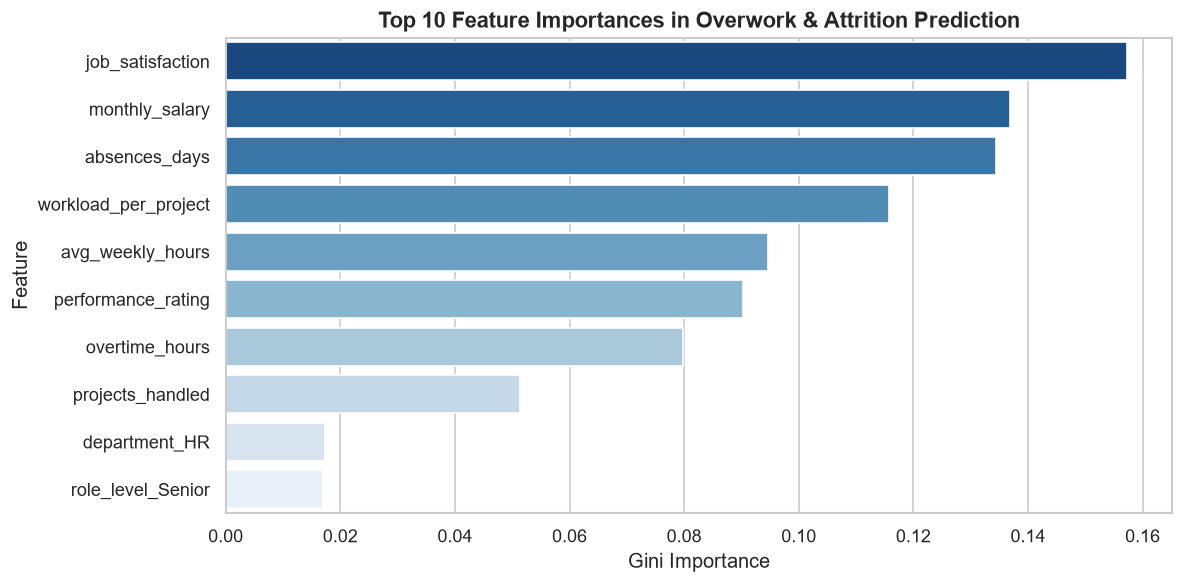

In [ ]:
# Feature Importance Breakdown
importances = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False).reset_index(drop=True)

display(importances.head(10))

plt.figure(figsize=(10, 5))
sns.barplot(data=importances.head(10), x='Importance', y='Feature', palette='Blues_r')
plt.title('Top 10 Feature Importances in Overwork & Attrition Prediction')
plt.xlabel('Gini Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

## 6. Operational Dashboard & Visualisations

C:\Users\Abinivesh M\AppData\Local\Temp\ipykernel_3484\2727238969.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=team_metrics, x='department', y='Avg_Weekly_Hours', ax=ax1, palette='mako')
C:\Users\Abinivesh M\AppData\Local\Temp\ipykernel_3484\2727238969.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=spike_analysis, x='workload_category', y='Attrition_Rate_Pct', ax=ax4, palette='Reds_r')


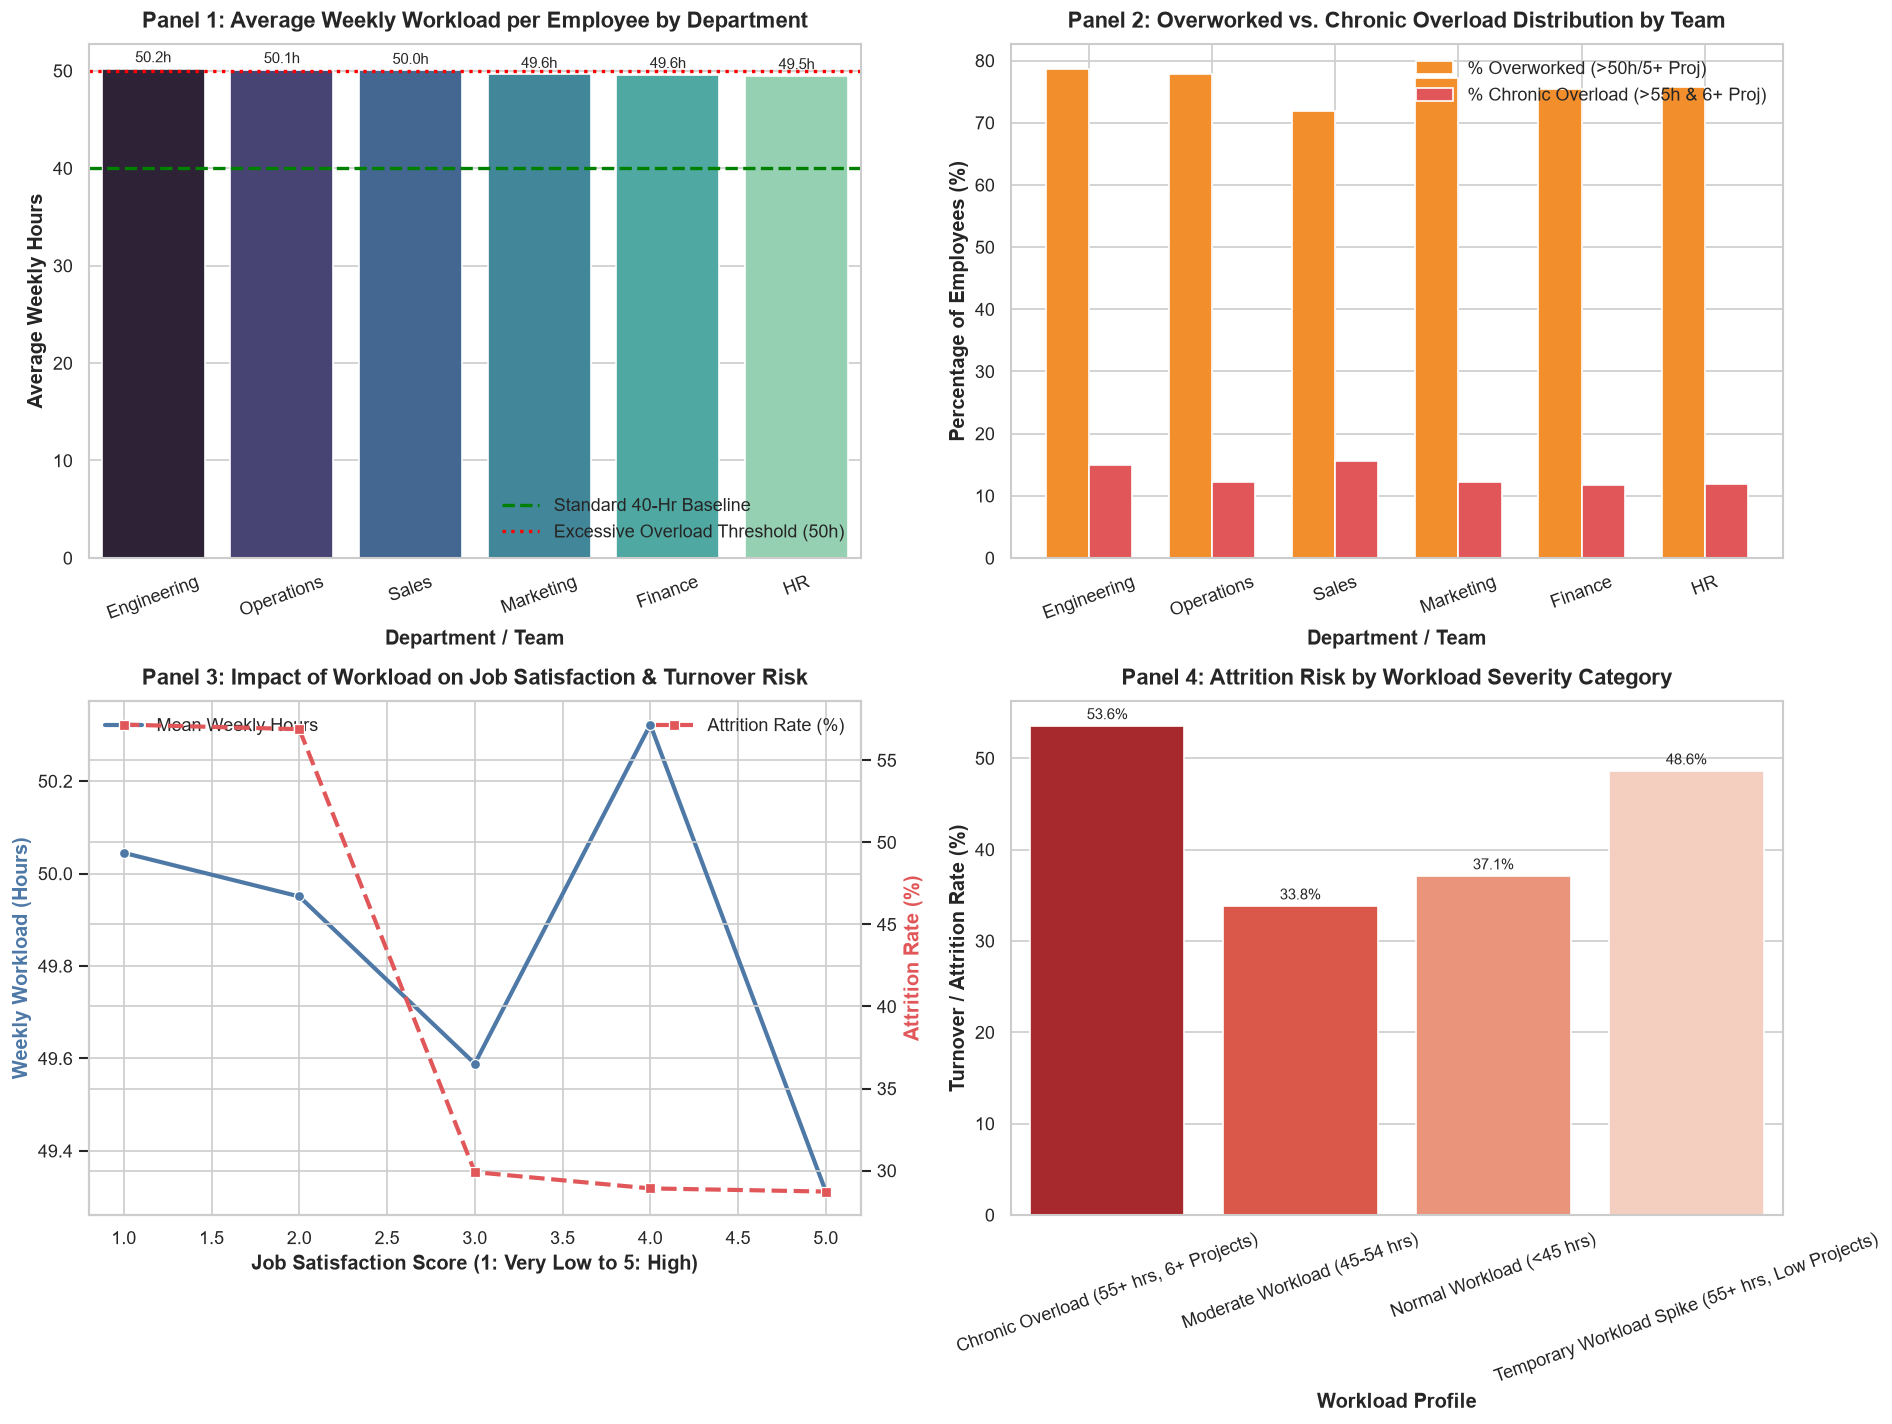

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Panel 1: Team Overtime & Workload Comparison
ax1 = axes[0, 0]
sns.barplot(data=team_metrics, x='department', y='Avg_Weekly_Hours', ax=ax1, palette='mako')
ax1.axhline(40, color='green', linestyle='--', linewidth=2, label='Standard 40-Hr Baseline')
ax1.axhline(50, color='red', linestyle=':', linewidth=2, label='Excessive Overload Threshold (50h)')
ax1.set_title('Panel 1: Average Weekly Workload per Employee by Department', pad=10)
ax1.set_xlabel('Department / Team', fontweight='bold')
ax1.set_ylabel('Average Weekly Hours', fontweight='bold')
ax1.tick_params(axis='x', rotation=20)
ax1.legend(loc='lower right')
for p in ax1.patches:
    ax1.annotate(f"{p.get_height():.1f}h", (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='bottom', fontsize=9, xytext=(0, 2), textcoords='offset points')

# Panel 2: Overworked vs Chronic Overload Share by Team
ax2 = axes[0, 1]
x = np.arange(len(team_metrics))
width = 0.35
ax2.bar(x - width/2, team_metrics['Overworked_Employee_Pct'], width, label='% Overworked (>50h/5+ Proj)', color='#f28e2b')
ax2.bar(x + width/2, team_metrics['Chronic_Overload_Pct'], width, label='% Chronic Overload (>55h & 6+ Proj)', color='#e15759')
ax2.set_title('Panel 2: Overworked vs. Chronic Overload Distribution by Team', pad=10)
ax2.set_xlabel('Department / Team', fontweight='bold')
ax2.set_ylabel('Percentage of Employees (%)', fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(team_metrics['department'], rotation=20)
ax2.legend(loc='upper right')

# Panel 3: Workload vs Job Satisfaction & Attrition Rate
ax3 = axes[1, 0]
sns.lineplot(data=sat_analysis, x='job_satisfaction', y='Mean_Weekly_Hours', ax=ax3, marker='o', color='#4e79a7', linewidth=2.5, label='Mean Weekly Hours')
ax3_twin = ax3.twinx()
sns.lineplot(data=sat_analysis, x='job_satisfaction', y='Attrition_Rate_Pct', ax=ax3_twin, marker='s', color='#e15759', linewidth=2.5, linestyle='--', label='Attrition Rate (%)')
ax3.set_title('Panel 3: Impact of Workload on Job Satisfaction & Turnover Risk', pad=10)
ax3.set_xlabel('Job Satisfaction Score (1: Very Low to 5: High)', fontweight='bold')
ax3.set_ylabel('Weekly Workload (Hours)', color='#4e79a7', fontweight='bold')
ax3_twin.set_ylabel('Attrition Rate (%)', color='#e15759', fontweight='bold')

# Panel 4: Workload Category vs Attrition Probability
ax4 = axes[1, 1]
sns.barplot(data=spike_analysis, x='workload_category', y='Attrition_Rate_Pct', ax=ax4, palette='Reds_r')
ax4.set_title('Panel 4: Attrition Risk by Workload Severity Category', pad=10)
ax4.set_xlabel('Workload Profile', fontweight='bold')
ax4.set_ylabel('Turnover / Attrition Rate (%)', fontweight='bold')
ax4.tick_params(axis='x', rotation=20)
for p in ax4.patches:
    ax4.annotate(f"{p.get_height():.1f}%", (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='bottom', fontsize=9, xytext=(0, 2), textcoords='offset points')

plt.tight_layout()
plt.show()